## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
filepath_nn_change = '/bettik/ockendeh/NEMO_simulations/TGCC/nn_output_melt_starter.nc'

In [3]:
output_melt = xr.open_dataset(filepath_nn_change)
print('Highest melt:', np.min(output_melt.melt.values)) 
print('Highest refreezing:', np.max(output_melt.melt.values))

Highest melt: -0.026043199085674495
Highest refreezing: 0.0004887308709618573


(array([ 8.,  0.,  0., 14.,  0.,  0., 17.,  9., 25.,  0.,  9., 36., 29.,
        28.,  9., 20., 71., 42., 14., 42., 72., 70., 56., 32., 67., 10.,
        19., 21., 12.,  5., 12., 10.,  4.,  9.,  4.,  2., 12.,  4.,  1.,
         3.]),
 array([-5.79396417, -5.68872271, -5.58348124, -5.47823978, -5.37299832,
        -5.26775686, -5.16251539, -5.05727393, -4.95203247, -4.84679101,
        -4.74154954, -4.63630808, -4.53106662, -4.42582516, -4.32058369,
        -4.21534223, -4.11010077, -4.00485931, -3.89961784, -3.79437638,
        -3.68913492, -3.58389346, -3.47865199, -3.37341053, -3.26816907,
        -3.16292761, -3.05768614, -2.95244468, -2.84720322, -2.74196176,
        -2.63672029, -2.53147883, -2.42623737, -2.32099591, -2.21575444,
        -2.11051298, -2.00527152, -1.90003006, -1.79478859, -1.68954713,
        -1.58430567]),
 <BarContainer object of 40 artists>)

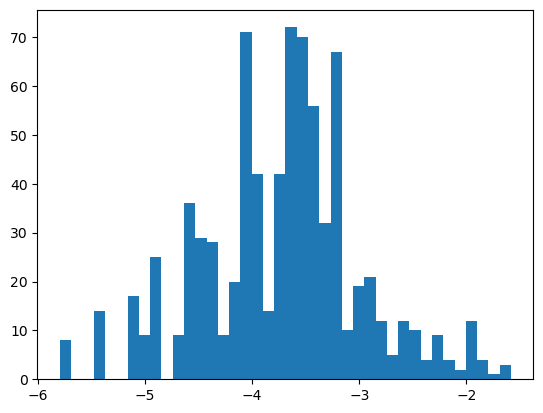

In [4]:
plt.hist(np.log10(np.abs(output_melt.melt.values[output_melt.melt.values != 0])), bins = 40)

/tmp/ipykernel_273187/3748269529.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
/tmp/ipykernel_273187/3748269529.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_273187/3748269529.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
/tmp/ipykernel_273187/3748269529.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


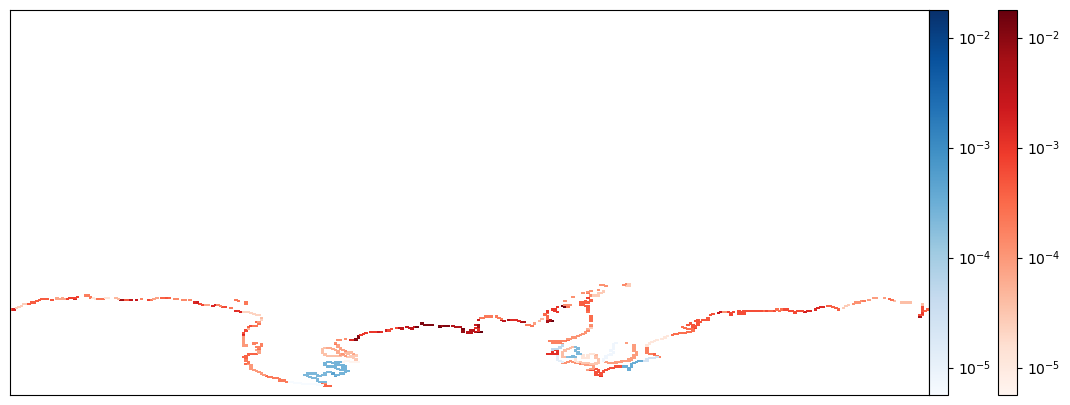

In [5]:
melt = xr.open_dataset(filepath_nn_change)# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-5,-4,-3,-2))
cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
#ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [6]:
altered = melt.melt.values
altered[altered < -2.5e-4] = -2.5e-4

/tmp/ipykernel_273187/3803294793.py:2: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-altered), cmap = 'Reds')
/tmp/ipykernel_273187/3803294793.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_273187/3803294793.py:7: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(altered), cmap = 'Blues')
/tmp/ipykernel_273187/3803294793.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


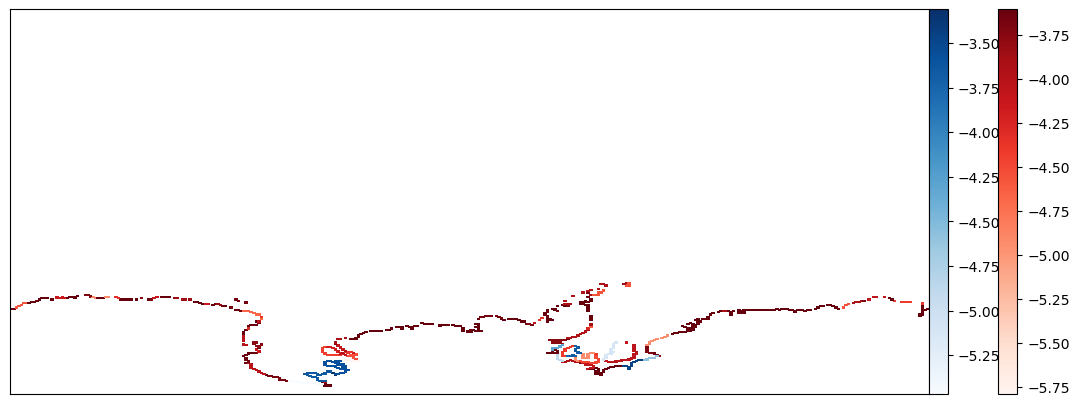

In [7]:
fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-altered), cmap = 'Reds')
#im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
#cbar.set_ticks((-5,-4,-3,-2))
#cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))
im = plt.pcolor(np.log10(altered), cmap = 'Blues')
#im.set_clim(-5.25,-1.75)
cbar = plt.colorbar(im, ax= ax, pad = 0)
#cbar.set_ticks((-5,-4,-3,-2))
#cbar.set_ticklabels((('10$^{-5}$'), ('10$^{-4}$'), ('10$^{-3}$'), ('10$^{-2}$')))

ax.set_xticks([]);
ax.set_yticks([]);
#ax.set_ylim(0,110)

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [15]:
output_melt = xr.open_dataset(filepath_nn_change)

In [16]:
output_melt.melt.values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [17]:
output_melt['melt'] = xr.DataArray(altered,
                                    coords=output_melt['melt'].coords,
                                    dims=output_melt['melt'].dims,
                                    attrs=output_melt['melt'].attrs)
output_melt = output_melt.fillna(0)
print('Nan values filled')

Nan values filled


In [18]:
filepath_this_nn_output = '/bettik/ockendeh/NEMO_simulations/TGCC/nn_output_altered.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

You have saved the nn output to: /bettik/ockendeh/NEMO_simulations/TGCC/nn_output_altered.nc


In [19]:

altered2 = altered
altered2[altered2 < 0 ] = 0
altered2[altered2 > 0 ] = 0

In [20]:
output_melt2 = xr.open_dataset(filepath_nn_change)
output_melt2['melt'] = xr.DataArray(altered2,
                                    coords=output_melt2['melt'].coords,
                                    dims=output_melt2['melt'].dims,
                                    attrs=output_melt2['melt'].attrs)
output_melt2 = output_melt2.fillna(0)
print('Nan values filled')

Nan values filled


In [21]:
filepath_this_nn_output = '/bettik/ockendeh/NEMO_simulations/TGCC/nn_output_altered0.nc'
output_melt.to_netcdf(filepath_this_nn_output)
print('You have saved the nn output to:', filepath_this_nn_output)

You have saved the nn output to: /bettik/ockendeh/NEMO_simulations/TGCC/nn_output_altered0.nc
